In [1]:
from idun_guardian_sdk import GuardianClient, FileTypes
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
my_recording_id = "1770732156922"


if __name__ == "__main__":
    client = GuardianClient(api_token=my_api_token)
    client.download_file(recording_id=my_recording_id, file_type=FileTypes.EEG)

[INFO] 2026-02-10 15:05:18,195: [API]: File saved: 'eeg_1770732156922.csv'


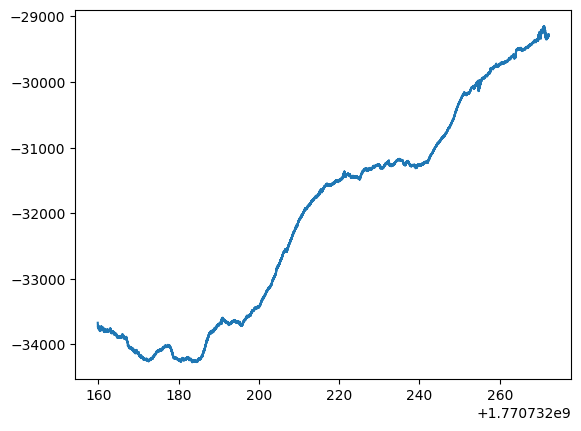

In [ ]:
data = pd.read_csv('eeg_1770732156922.csv')
dt = np.median(np.diff(data['timestamp']))
fs = 1 / dt
plt.plot(data['timestamp'], data['ch1'])

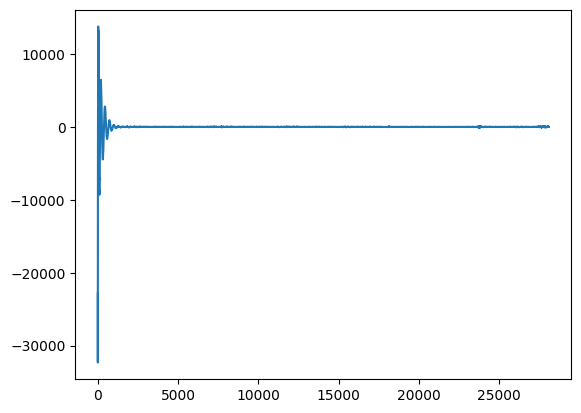

In [4]:
sos_notch = signal.iirdesign(
    wp=[46, 54], ws=[48, 52],
    gpass=1, gstop=60,
    ftype="cheby2", output="sos", fs=fs
)

sos_hp = signal.iirdesign(
    wp=1, ws=0.5, 
    gpass=1, gstop=40, 
    analog=False, ftype="butter", output="sos", fs=fs)

data_filt = signal.sosfilt(sos_notch, data['ch1'], zi=None)
data_filt = signal.sosfilt(sos_hp, data_filt, zi=None)
plt.plot(data_filt)

In [10]:
def epoch_signal(x, fs, epoch_sec=2.0):
    L = int(epoch_sec * fs)
    n_epochs = len(x) // L
    x = x[:n_epochs * L]
    return x.reshape(n_epochs, L)

def mad(a):
    med = np.median(a)
    return np.median(np.abs(a - med)) + 1e-12

epochs = epoch_signal(data_filt, fs, epoch_sec=2.0)

# metrics per epoch
ptp = np.ptp(epochs, axis=1)
rms = np.sqrt(np.mean(epochs**2, axis=1))
dmax = np.max(np.abs(np.diff(epochs, axis=1)), axis=1)

# robust thresholds: median + k*MAD
def robust_thresh(v, k=6.0):
    return np.median(v) + k * mad(v)

ptp_th = robust_thresh(ptp, k=6)
rms_th = robust_thresh(rms, k=6)
dmax_th = robust_thresh(dmax, k=6)

good = (ptp < ptp_th) & (rms < rms_th) & (dmax < dmax_th)

epochs_good = epochs[good]
print(f"Kept {good.mean()*100:.1f}% of epochs ({good.sum()}/{len(good)})")

Kept 83.9% of epochs (47/56)


In [11]:
transformed_data = np.fft.rfft(data_filt)
freqs = np.fft.rfftfreq(len(data_filt), d=1/fs)
power = np.abs(transformed_data) ** 2

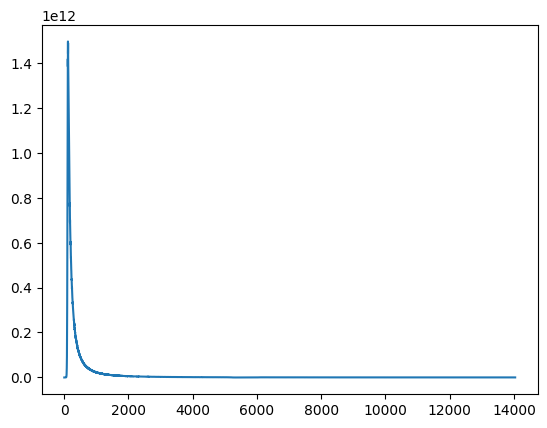

In [12]:
plt.plot(power)

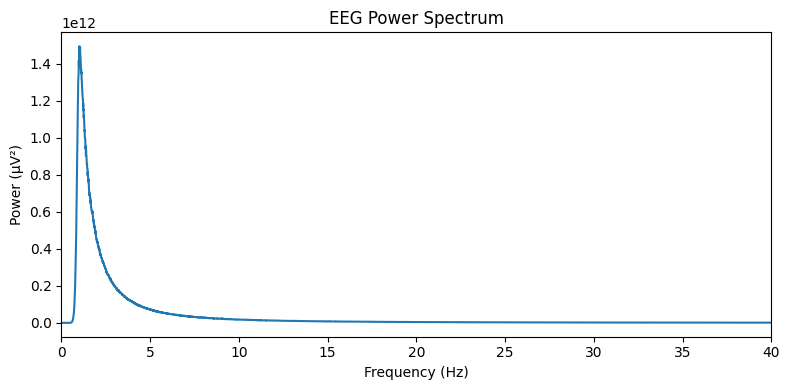

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²)")
plt.title("EEG Power Spectrum")
plt.tight_layout()
plt.show()

In [14]:
def band_power(freqs, power, fmin, fmax):
    idx = np.logical_and(freqs >= fmin, freqs < fmax)
    return np.sum(power[idx])

delta = band_power(freqs, power, 0.5, 4)
theta = band_power(freqs, power, 4, 8)
alpha = band_power(freqs, power, 8, 13)
beta  = band_power(freqs, power, 13, 30)

total = delta + theta + alpha + beta

print("Relative power:")
print(f"Delta: {delta/total:.2%}")
print(f"Theta: {theta/total:.2%}")
print(f"Alpha: {alpha/total:.2%}")
print(f"Beta:  {beta/total:.2%}")

Relative power:
Delta: 79.50%
Theta: 11.78%
Alpha: 4.54%
Beta:  4.18%
